## Code:Airlines passengers count prediction(time series) using RNN.

In [40]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', '2210037(phonebook).pdf', '2210037.cpp', 'Panchayat (1).S04E01.mkv', 'Panchayat (1).S04E02.mkv', 'Panchayat (1).S04E03.mkv', 'Panchayat (1).S04E04.mkv', 'Panchayat (1).S04E05.mkv', 'Panchayat (1).S04E06.mkv', 'Panchayat (1).S04E07.mkv', 'Panchayat (1).S04E08.mkv', 'Panchayat.S04E01.mkv', 'Panchayat.S04E02.mkv', 'Panchayat.S04E03.mkv', 'Panchayat.S04E04.mkv', 'Panchayat.S04E05.mkv', 'Panchayat.S04E06.mkv', 'Panchayat.S04E07.mkv', 'Panchayat.S04E08.mkv', 'EV_asssignment(new).pdf', '2210037(EV).pdf', 'EV_asssignment[1].docx', '2210037(EV).docx', '2210003_2210006_2210035_2210037-final.docx', '2210003_2210006_2210035_2210037-final.pdf', '2210037.letter.pdf', 'Classroom', 'AirPassengers.csv']


In [43]:
# Step 1: Load Dataset
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/AirPassengers.csv")
print(df.head())


         date  value
0  1949-01-01    112
1  1949-02-01    118
2  1949-03-01    132
3  1949-04-01    129
4  1949-05-01    121


In [44]:
df["value"].values

array([112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 115,
       126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140, 145, 150,
       178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180, 193,
       181, 183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236, 235,
       229, 243, 264, 272, 237, 211, 180, 201, 204, 188, 235, 227, 234,
       264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270, 315,
       364, 347, 312, 274, 237, 278, 284, 277, 317, 313, 318, 374, 413,
       405, 355, 306, 271, 306, 315, 301, 356, 348, 355, 422, 465, 467,
       404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505, 404,
       359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463, 407,
       362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390,
       432])

In [45]:
# Step 2: Data Preprocessing


data=df["value"].values.reshape(-1,1)

## -1 = "Figure out this dimension automatically"
# reshape(-1, 1) means: Column 1: Make it 1 column
# Rows: Automatically calculate based on data length

# If data has 144 elements:
# 144 rows × 1 column = 144 elements.we need this shape because PyTorch RNN expects	Input shape: (batch, sequence, features) where feutures need 2D vector.



### Why 1D → 2D? reshape(-1,1)? 
RNN expects: (samples, sequence_length, features)

(144,) is just 1D array.But RNN needs to know: "How many features at each time step?"

1D Array - Shape (144,)

[112, 118, 132, 129, 121, ...]---> Values, but NO feature dimension!

2D Array - Shape (144, 1)
[[112],   # Each time step has 

 [118],   # its own feature vector

 [132],   # of size 1

 [129],

 [121],

 ...]

 At each time step t, RNN does:

hidden_t = tanh( input_t @ W_ih + previous_hidden @ W_hh )

input_t must be a VECTOR, not a single number.

with 1D input_t = 112 which is just a number!Can't multiply with weight matrix.input shape here(1,1) then weight Wi shape is (1,hidden_size).......here hidden_size=neurons.

In [46]:
data.shape

(144, 1)

In [47]:
# Step 3: Normalize Data

scaler = MinMaxScaler(feature_range=(0, 1))  # feature_range=(0, 1) means that the data will be scaled to be between 0 and 1. This is a common practice in machine learning to improve the performance of the model by ensuring that all features contribute equally to the learning process.
data_scaled = scaler.fit_transform(data)


#### Normalization of data(scaling).

"MinMaxScaler shrinks big numbers to 0-1 range so neural networks can learn smoothly, like zooming out on a map to see everything clearly.

**Without Scaling (Bad):**

RNN sees numbers like:

[112, 118, 132, 622, ...]

Problems:

- Large numbers (622) dominate learning
- Small numbers (112) get ignored
- Activation functions (tanh/sigmoid) work best with small numbers
- Training is unstable.

**With Scaling (Good):**

RNN sees numbers like:

[0.02, 0.03, 0.05, 1.0, ...]

Benefits:

- All features treated equally
- Activation functions happy (0-1 range)
- Faster training
- Better predictions.
  
Formula:

scaled_value = (original - min_value) / (max_value - min_value)



In [48]:
data_scaled    # This is the normalized data, where all values are scaled to be between 0 and 1. This helps the RNN model to learn more effectively by ensuring that all features contribute equally to the learning process.

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

In [49]:
# step:4 Create sliding window(Creates input-output pairs from time series data for supervised learning.)

def create_sequences(data,seq_length):
    x=[]
    y=[]
    for i in range(len(data)-seq_length):
        x.append(data[i:i+seq_length])     
        y.append(data[i+seq_length])
    return np.array(x),np.array(y)     # Convert lists to numpy arrays for easier manipulation and compatibility with machine learning models.PyTorch CANNOT use lists directly
seq_length=12
x,y=create_sequences(data_scaled,seq_length)

### Create sliding window.

Sliding window turns ONE long sequence into MANY small lessons for the model to learn from.

suppose, seq_length = 3, and we have a time series data of monthly airline passengers for 12 months:
    
**When i = 0:**

X.append(data[0:3])    # [112, 118, 132]  ← Jan, Feb, Mar

y.append(data[3])      # 129                ← Apr (to predict)

Model learns: [Jan, Feb, Mar] → Apr = 129

**When i = 1:**

X.append(data[1:4])    # [118, 132, 129]  ← Feb, Mar, Apr

y.append(data[4])      # 121                ← May (to predict)

Model learns: [Feb, Mar, Apr] → May = 121

we take seq_length = 12  because:

Airline passenger data has YEARLY patterns:

- More passengers in summer
- Less in winter
- Repeats every 12 months!

Using 12 months helps model learn:

"If last July was high, this July might be high too!"

In [50]:
print(x.shape)  # x.shape is (132, 12, 1) because we have 132 sequences of length 12, and each value is a single feature (the number of passengers). (132 = 144 total data points - 12 sequence length)  shape format is (number of sequences, sequence length, number of features)
print(y.shape)

(132, 12, 1)
(132, 1)


In [51]:
# step:5 Convert to PyTorch tensors

x=torch.tensor(x,dtype=torch.float32)    # x is converted to a PyTorch tensor with data type float32. This is necessary because PyTorch models expect input data to be in the form of tensors, and using float32 ensures that the model can perform calculations efficiently while maintaining sufficient precision for training.
y=torch.tensor(y,dtype=torch.float32)

x

tensor([[[0.0154],
         [0.0270],
         [0.0541],
         ...,
         [0.0290],
         [0.0000],
         [0.0270]],

        [[0.0270],
         [0.0541],
         [0.0483],
         ...,
         [0.0000],
         [0.0270],
         [0.0212]],

        [[0.0541],
         [0.0483],
         [0.0328],
         ...,
         [0.0270],
         [0.0212],
         [0.0425]],

        ...,

        [[0.5849],
         [0.4981],
         [0.5811],
         ...,
         [1.0000],
         [0.9691],
         [0.7799]],

        [[0.4981],
         [0.5811],
         [0.6042],
         ...,
         [0.9691],
         [0.7799],
         [0.6892]],

        [[0.5811],
         [0.6042],
         [0.5541],
         ...,
         [0.7799],
         [0.6892],
         [0.5521]]])

In [52]:
x

tensor([[[0.0154],
         [0.0270],
         [0.0541],
         ...,
         [0.0290],
         [0.0000],
         [0.0270]],

        [[0.0270],
         [0.0541],
         [0.0483],
         ...,
         [0.0000],
         [0.0270],
         [0.0212]],

        [[0.0541],
         [0.0483],
         [0.0328],
         ...,
         [0.0270],
         [0.0212],
         [0.0425]],

        ...,

        [[0.5849],
         [0.4981],
         [0.5811],
         ...,
         [1.0000],
         [0.9691],
         [0.7799]],

        [[0.4981],
         [0.5811],
         [0.6042],
         ...,
         [0.9691],
         [0.7799],
         [0.6892]],

        [[0.5811],
         [0.6042],
         [0.5541],
         ...,
         [0.7799],
         [0.6892],
         [0.5521]]])

In [53]:
# step:6 Split into train and test sets:

train_size = int(len(x) * 0.8)

X_train = x[:train_size]
y_train = y[:train_size]

X_test = x[train_size:]
y_test = y[train_size:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([105, 12, 1]),
 torch.Size([105, 1]),
 torch.Size([27, 12, 1]),
 torch.Size([27, 1]))

In [54]:
# step:7 Define RNN model

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)  # batch_first=True means that the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature). This is more intuitive and easier to work with when dealing with batches of data.
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.rnn(x)  # RNN forward
        out = out[:, -1, :]   # Last time step
        out = self.fc(out)    # Final output
        return out


**nn.RNN contains:**

- Weights for input: W_ih (input_size × hidden_size)
- Weights for hidden: W_hh (hidden_size × hidden_size)
- Bias: b_ih, b_hh
- nn.RNN - The Memory Layer

**nn.Linear contains:**

- Weights: W (hidden_size × output_size)
- Bias: b (output_size)
- nn.Linear - The Decision Layer and make predictions of all sequences

These weights are LEARNED during training!

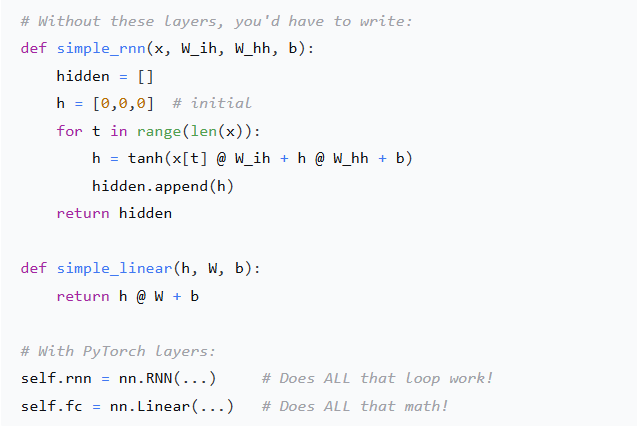

In [55]:
# step:8 initialize model, define loss and optimizer

input_size = 1
hidden_size = 32
output_size = 1

model = RNNModel(input_size, hidden_size, output_size)

criterian=nn.MSELoss()       # MSELoss is used for regression problems where the goal is to minimize the mean squared error between the predicted values and the actual values. In this case, we are predicting the number of passengers, which is a continuous value, so MSELoss is appropriate.
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)     # Adam optimizer is an adaptive learning rate optimization algorithm that combines the advantages of both AdaGrad and RMSProp. It computes individual adaptive learning rates for each parameter from estimates of first and second moments of the gradients, which helps in faster convergence and better performance when training deep learning models.

# for classification problems, we would typically use a loss function like CrossEntropyLoss, which is designed for multi-class classification tasks. However, since we are dealing with a regression problem (predicting the number of passengers), MSELoss is the appropriate choice.

In [61]:
# step:9 Train the model

losses=[]
epochs=100
for epoch in range(epochs):
    outputs=model(X_train)  # Forward pass: Compute predicted y by passing x to the model
    
    loss=criterian(outputs,y_train)  # Compute loss of all the sequences at once 105 samples in the training set, so we compute the loss for all 105 samples together.
    
    # backward
    optimizer.zero_grad()      # Clear gradients before backward pass to prevent accumulation of gradients from previous iterations.
    loss.backward()            # Backpropagation: Compute gradients of the loss with respect to model parameters.
    optimizer.step()           # Update parameters using the computed gradients.
    
    losses.append(loss.item())  # Append the scalar value of the loss to the losses list for later analysis and visualization.
    if (epoch+1)%20==0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")  # Print the loss every 20 epochs to monitor the training progress. loss.item() is used to get the scalar value of the loss tensor for easier readability.

Epoch [20/100], Loss: 0.0035
Epoch [40/100], Loss: 0.0018
Epoch [60/100], Loss: 0.0014
Epoch [80/100], Loss: 0.0012
Epoch [100/100], Loss: 0.0016


In [65]:
# step:10 prediction

model.eval()  # Set the model to evaluation mode, which disables dropout and batch normalization layers (if any) and ensures that the model behaves correctly during inference.
with torch.no_grad():  # Disable gradient calculation for inference, which reduces memory usage and speeds up computations since we don't need gradients during prediction.
    predictions = model(X_test)  # Generate predictions for the test set using the trained model.
    
predictions = scaler.inverse_transform(predictions.numpy())
print(predictions)


[[386.35812]
 [370.09082]
 [341.78464]
 [393.33563]
 [398.34933]
 [353.2311 ]
 [379.20096]
 [395.34973]
 [476.00848]
 [508.49423]
 [537.8836 ]
 [512.87213]
 [428.2598 ]
 [394.78333]
 [373.8856 ]
 [438.14127]
 [443.59714]
 [400.29968]
 [396.49432]
 [452.71674]
 [511.1332 ]
 [558.9073 ]
 [580.58325]
 [540.886  ]
 [470.43134]
 [454.63342]
 [412.62717]]


In [58]:
# step:11 Inverse transform predictions and actual values to original scale

predictions = scaler.inverse_transform(predictions.numpy())  # Convert predictions from PyTorch tensor to NumPy array and then inverse transform to original scale.
y_test = scaler.inverse_transform(y_test.numpy())  # Convert actual values from PyTorch tensor to NumPy array and then inverse transform to original scale.

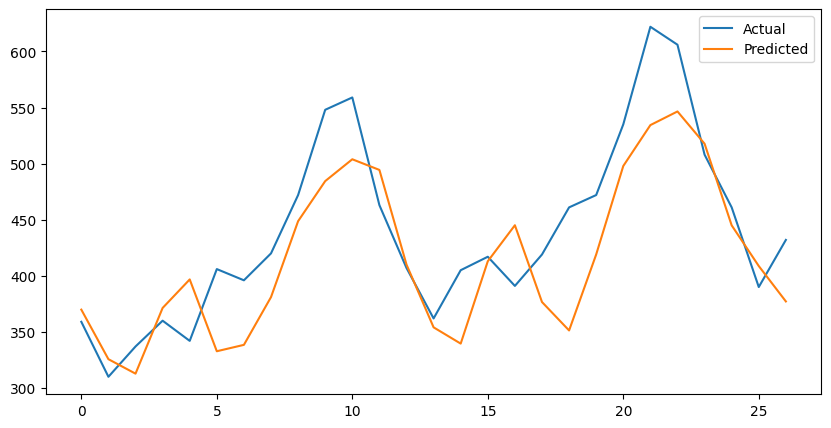

In [60]:
# step:12 plot result

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

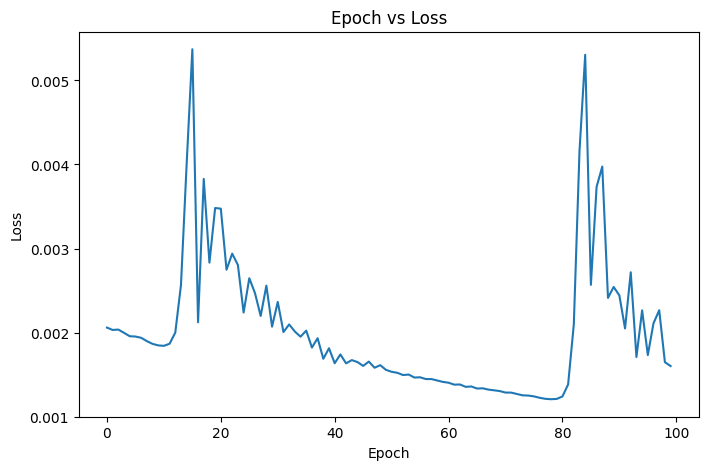

In [62]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.show()

In [ ]:
# simple first sequence prediction of train data
sample_input = X_train[0]

print(sample_input.shape)
sample_input = sample_input.unsqueeze(0) # unsqueeze(0) adds a new dimension at the specified position (in this case, at position 0, which is the batch dimension). This is necessary because the model expects input in the shape (batch_size, sequence_length, num_features), and by unsqueezing, we are creating a batch of size 1 for our single sequence input.

print(sample_input.shape)

model.eval()

with torch.no_grad():
    sample_prediction = model(sample_input)

sample_prediction = scaler.inverse_transform(sample_prediction.numpy())

print("Predicted value:", sample_prediction[0][0])

# 13th value=115 in actual data csv file

torch.Size([12, 1])
torch.Size([1, 12, 1])
Predicted value: 134.79048


In [68]:
X_train[0]
o = scaler.inverse_transform(X_train[0].numpy())
o

array([[112.],
       [118.],
       [132.],
       [129.],
       [121.],
       [135.],
       [148.],
       [148.],
       [136.],
       [119.],
       [104.],
       [118.]], dtype=float32)

### What happens in one epoch:

1. ALL of X_train (105 sequences) goes into model
outputs = model(X_train)  # ← ONE operation!

2. Model processes ALL 105 sequences in parallel

3. Returns ALL 105 predictions at once
outputs.shape  # (105, 1)  ← 105 predictions!

4. Compare ALL predictions with ALL targets
loss = criterion(outputs, y_train)  # ← ONE loss for ALL

y_train.shape = (105, 1)


Assume X_train has 3 sequences:

X_train = tensor([

    [ [1], [2], [3] ],  # Sequence 1

    [ [4], [5], [6] ],  # Sequence 2  

    [ [7], [8], [9] ]   # Sequence 3

])  # Shape: (3, 3, 1)

ONE forward pass processes ALL:
outputs = model(X_train)

Inside model:

- RNN processes all 3 sequences in parallel
- Each goes through its 3 time steps
- Returns 3 predictions

outputs.shape  # (3, 1)  ← 3 predictions at once!


For EACH sequence in the batch:

Sequence 1: [1,2,3] → RNN processes step by step → final memory → prediction1

Sequence 2: [4,5,6] → RNN processes step by step → final memory → prediction2  

Sequence 3: [7,8,9] → RNN processes step by step → final memory → prediction3

ALL AT THE SAME TIME (parallel processing)!

Output: [pred1, pred2, pred3]  ← shape (3,1)


Epoch 1:

    ALL 105 sequences → model → 105 predictions

    Compare with 105 targets → calculate 1 loss value

    Update weights based on ALL errors

Epoch 2:

    ALL 105 sequences → model (with updated weights) → new predictions

    Compare → new loss → update again

Each epoch sees ALL training data once!